# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Ten trials recorded, ordered by objective: trial_09 0.1657 (BEST), trial_05 0.1863, trial_01 0.1907, trial_07 0.1940, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective spread is the gamma term, dominated by low transmission, and it is violently unstable -- trial_09 (best) and trial_10 (worst) were near-neighbours in parameter space (differing mainly in lr_mu) and differed by a runaway 1 nW Trans05 gamma (+179%). The current best recipe (trial_09) is sigma_ref ~25, lr_mu ~6, lr_gamma ~0.88, anneal ~0.41. TPE (10/5) is exploiting; its top picks flank that region. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 2.8070 | {"gamma_anneal": 0.3744583968300862, "lr_gamma": 0.8751028119093756, "lr_mu": 28.20527557400924, "sigma_ref": 7.59547898798596}
 2 | 3.4551 | {"gamma_anneal": 0.4187801667023736, "lr_gamma": 0.8827203800126975, "lr_mu": 5.799287816635503, "sigma_ref": 20.760791890079837}
 3 | 3.2134 | {"gamma_anneal": 0.5834729432963928, "lr_gamma": 0.8598709538953955, "lr_mu": 9.00945430011219, "sigma_ref": 20.378030922680427}
 4 | 3.1140 | {"gamma_anneal": 0.33392993151706185, "lr_gamma": 0.8417621470227867, "lr_mu": 18.097822112966956, "sigma_ref": 23.393104424352483}
 5 | 2.6063 | {"gamma_anneal": 0.6719582311877756, "lr_gamma": 0.8789734203491643, "lr_mu": 23.993974336139157, "sigma_ref": 5.0}
 6 | 2.6859 | {"gamma_anneal": 0.1505767156209145, "lr_gamma": 0.8608519297739538, "lr_mu": 12.971814161007622, "sigma_ref": 25.0}
 7 | 2.5151 | {"gamma_anneal": 0.7473269066547529, "lr_gamma": 0.899623175704092, "lr_mu": 5.85125697367594, "sig

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (10/5) ranks by expected improvement. The highest-EI candidate is candidate 2 (EI 3.46): gamma_anneal 0.419, lr_gamma 0.883, lr_mu 5.80, sigma_ref 20.76 -- this is essentially the current best recipe (trial_09: sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, anneal 0.410), differing only by a somewhat lower sigma_ref. The runner-ups (candidate 3: anneal 0.583, lr_mu 9.01; candidate 4: anneal 0.334, lr_mu 18.10) sit further from the best region. Because trial_10 showed this neighbourhood carries high variance, but the expected-improvement criterion and the best-trial precedent both point the same way, I follow TPE's top pick. I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # highest-EI TPE pick, close to the trial_09 best recipe


chosen: {'gamma_anneal': 0.4187801667023736, 'lr_gamma': 0.8827203800126975, 'lr_mu': 5.799287816635503, 'sigma_ref': 20.760791890079837}
Running  1nW Trans05 ... 

μ 9.39 -> 4.71 | γ 8.5 -> 2.30 | NLL 1.28


Running  1nW Trans20 ... 

μ 17.32 -> 8.65 | γ 8.5 -> 9.80 | NLL 3.28


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.04 | γ 14.1 -> 13.79 | NLL 3.19


Running 3nW Trans100 ... 

μ 175.71 -> 86.80 | γ 14.1 -> 13.83 | NLL 2.90



Total: 2.4 min


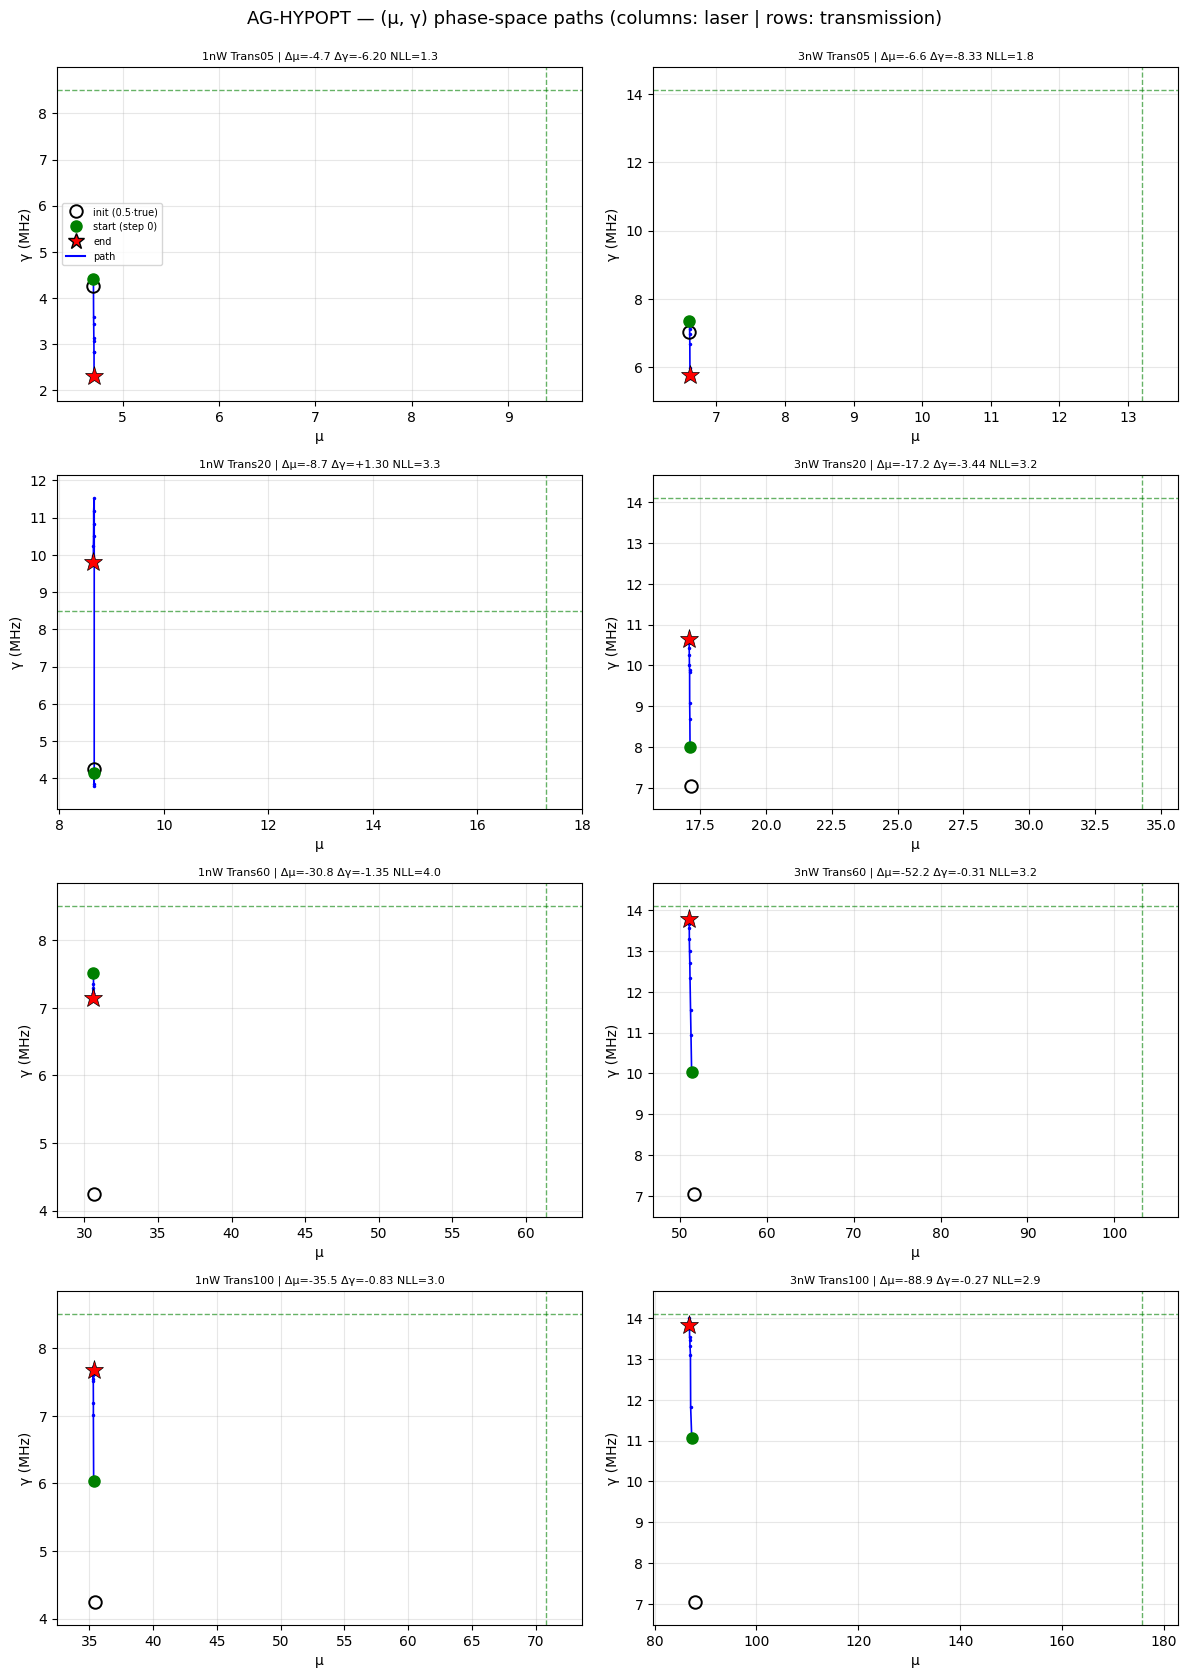

trial finished in 2.4 min
objective = 0.1883 ± 0.0381
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.71   -49.9 |     8.50    2.30   -72.9
1nW Trans20    17.32    8.65   -50.0 |     8.50    9.80   +15.3
1nW Trans60    61.37   30.60   -50.1 |     8.50    7.15   -15.9
1nW Trans100   70.82   35.33   -50.1 |     8.50    7.67    -9.8
3nW Trans05    13.20    6.62   -49.9 |    14.10    5.77   -59.1
3nW Trans20    34.28   17.09   -50.1 |    14.10   10.66   -24.4
3nW Trans60   103.20   51.04   -50.5 |    14.10   13.79    -2.2
3nW Trans100  175.71   86.80   -50.6 |    14.10   13.83    -1.9

μ: RMSE 40.725 (rel 50.2%, bias -30.558) | γ: RMSE 3.937 (rel 35.3%, bias -2.428)


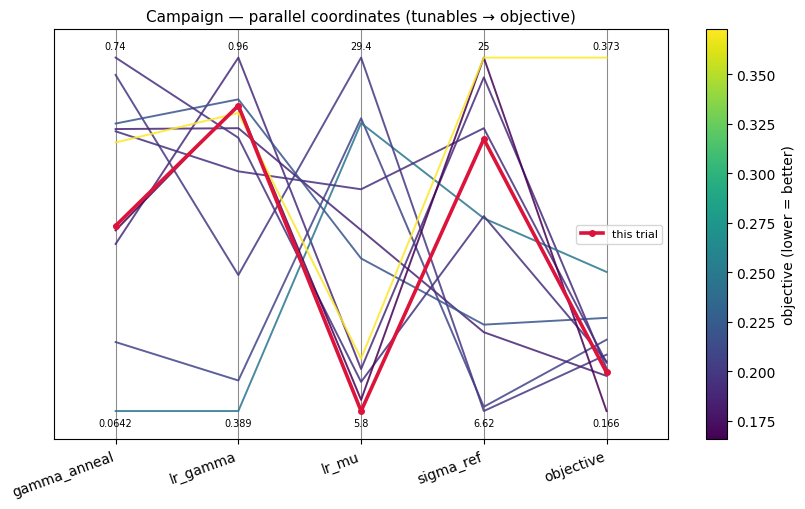

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 11, sixth TPE-driven trial; highest-EI pick, close to the trial_09 best recipe: sigma_ref 20.76, lr_mu 5.80, lr_gamma 0.883, gamma_anneal 0.419. Result: objective 0.1883 +/- 0.0381 -- third-best of the campaign (behind trial_09 0.1657 and trial_05 0.1863, ahead of trial_01 0.1907); runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.6; mu RMSE 40.73, relative 50.2%). gamma_fit is mostly good -- 3 nW Trans60/100: -2.2/-1.9%; 1 nW Trans20 overshoots +15.3% -- but still fails at Trans05 (1 nW -72.9%, 3 nW -59.1%), giving gamma RMSE 3.94 (relative 35.3%). So this near-trial_09 recipe landed solidly but did not reproduce trial_09's Trans05 improvement: the same region has now given the best (09), a mid-pack (11) and the worst (10) result, confirming high variance.

**Summary:** Trial 11 (sigma_ref 20.76, lr_mu 5.80, lr_gamma 0.883, gamma_anneal 0.419) -> objective 0.1883 +/- 0.0381, third best; near-trial_09 recipe but Trans05 gamma still collapsed (-73%/-59%).
**Key insight:** The trial_09 neighbourhood has now produced best, mid-pack and worst outcomes, confirming the objective is dominated by an unstable low-transmission gamma rather than by a reproducible hyperparameter optimum.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 11 (sigma_ref 20.76, lr_mu 5.80, lr_gamma 0.883, gamma_anneal 0.419): objective 0.1883 +/- 0.0381, third best; near-trial_09 recipe but Trans05 gamma still collapsed (-73%/-59%)'
KEY_INSIGHT = 'The trial_09 neighbourhood has now produced best, mid-pack and worst outcomes, confirming the objective is dominated by an unstable low-transmission gamma rather than a reproducible hyperparameter optimum.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
